### Imports and Setup

In [1]:
import os
from concurrent.futures import ThreadPoolExecutor
import concurrent

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import yaml
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import precision_score, recall_score, accuracy_score, precision_recall_curve
from scipy.optimize import minimize, least_squares
from PIL import Image
import pandas as pd
import gtsam
import h5py
import time

from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.datasets.dataloaders import get_dataloaders_range_classify_eval_loc, get_exp_data_dataloader_range_classify
from whale_gunshot_localization.utils.transformations import get_image_transform_range_classify, to_spect
from whale_gunshot_localization.utils.experimental import ClipAnalyzer, l2_standardize, MultilaterationOpt, MultilaterationGrid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# load config file
from whale_gunshot_localization import config

Using the GPU!


Settings for synthetic data evaluation

In [2]:
split = 'test'

### Prepare For Evaluation
Get dataloaders

In [3]:
dl = get_dataloaders_range_classify_eval_loc(splits=['val', 'test'],
                                        batch_size=128,
                                        transform=get_image_transform_range_classify(),
                                        squeeze=True,
                                        pin_memory=True,
                                        num_workers=20)

Load the desired model

In [4]:
model = TCNRangeAndClassify(input_size=dl[split].dataset.size[0], 
                                     num_channels=7*[368],
                                     kernel_size=6,
                                     dropout=0.05).to(device)

# load model weights
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'] + '/range_classify_12_low_snr', 'weights_best.pt'),
                        map_location=device)['model_state_dict']
model.load_state_dict(state_dict)

<All keys matched successfully>

## Evaluate Model On Synthetic Data
Get predictions and labels

In [5]:
def evaluate_model(model, dataloader):
    """
    Get lists of targets and predictions using a provided model and dataloader.
    
    Parameters
    ----------
    model : nn.Module
        model to be evaluated
    dataloader : data.DataLoader
        dataloader to use in model evaluation
    
    Returns
    -------
    r_p : array-like
        list of predicted ranges
    r_t : array-like
        list of true ranges
    c_p : array-like
        list of predicted classes
    c_t : array-like
        list of true classes
    outputs_all : array-like
        all model outputs
    """
    # put model in evaluatio mode
    model.eval()
    
    # get number of TOSSITs
    num_TOSSITs = dataloader.dataset.num_TOSSITs
    
    # get scale
    max_r = config['scaling']['max_r']
    
    # initialize arrays for results
    r_t, r_p, r_std, c_t, c_p, c_std, outputs_all = [[[] for _ in range(num_TOSSITs)] for _ in range(7)]
    x_t, y_t = [], []
    
    for inputs, target_c, target_r, target_x, target_y in tqdm(dataloader):

        # put data on device
        inputs = inputs.to(device)
        target_c = target_c.to(device)
        target_r = target_r.to(device)
        target_x = target_x.to(device)
        target_y = target_y.to(device)

        for t in range(num_TOSSITs):
            with torch.set_grad_enabled(False):
                # get outputs for a given TOSSIT
                outputs = model(inputs[:,t,...])

            outputs_all[t] += outputs.detach().tolist()

            # store x predictions and labels
            r_p[t] += (outputs[:,0].detach() * max_r).tolist()
            r_t[t] += target_r[:,t].detach().tolist()


            # store y predictions and labels
            c_p[t] += (F.softmax(outputs[:,1:].detach(),dim=1)[:,1] >= 0.5).tolist()
            c_t[t] += target_c.squeeze().detach().tolist()

        # store locations
        x_t += target_x.detach().tolist()
        y_t += target_y.detach().tolist()
    
    return np.asarray(r_p).T, np.asarray(r_t).T, np.asarray(c_p).T, np.asarray(c_t).T, np.asarray(x_t), np.asarray(y_t), np.transpose(np.asarray(outputs_all), (1, 0, 2))

In [6]:
r_p, r_t, c_p, c_t, x_t, y_t, outputs_all = evaluate_model(model, dl[split])

  0%|          | 0/409 [00:00<?, ?it/s]

In [7]:
acc = accuracy_score(c_t.flatten(), c_p.flatten())
prec = precision_score(c_t.flatten(), c_p.flatten())
recall = recall_score(c_t.flatten(), c_p.flatten())

print("statistics")
print("-------------------")
print(f'Accuracy: {np.around(acc, 5)}')
print(f'Precision: {np.around(prec, 5)}')
print(f'Recall: {np.around(recall, 5)}')

statistics
-------------------
Accuracy: 0.96409
Precision: 0.99387
Recall: 0.93384


In [8]:
acc = accuracy_score(c_t.sum(axis=1) >= 3, c_p.sum(axis=1) >= 3)
prec = precision_score(c_t.sum(axis=1) >= 3, c_p.sum(axis=1) >= 3)
recall = recall_score(c_t.sum(axis=1) >= 3, c_p.sum(axis=1) >= 3)

print("statistics")
print("-------------------")
print(f'Accuracy: {np.around(acc, 5)}')
print(f'Precision: {np.around(prec, 5)}')
print(f'Recall: {np.around(recall, 5)}')

statistics
-------------------
Accuracy: 0.97598
Precision: 1.0
Recall: 0.95189


In [105]:
def localize_gtsam(r_p, c_p, c_t):

    # get locations of TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # to store locations
    locs = np.zeros((r_p.shape[0], 2))
    
    # iterate through experimental call sets
    for s in tqdm(range(r_p.shape[0])):
        
        ones = np.where((c_p[s] == 1) & (c_t[s] == 1))[0]
        if len(ones) >= 3:
            # create factor graphs
            graph = gtsam.NonlinearFactorGraph()
            init_values = gtsam.Values()
            
            beacon_vars = []
            beacon_theta = 0
            for i, beacon_loc in enumerate(TOSSIT_locations):
                beacon_var = gtsam.symbol("b", i)
                beacon_vars.append(beacon_var)
                init_values.insert(beacon_var, gtsam.Pose2(*beacon_loc, beacon_theta))
                graph.add(
                    gtsam.PriorFactorPose2(
                        beacon_var,
                        gtsam.Pose2(*beacon_loc, beacon_theta),
                        gtsam.noiseModel.Isotropic.Sigma(3, 0.0004),
                    )
                )
            
            whale_var = gtsam.symbol("w", 0)
            rand_yx = np.random.rand(2)*100
            init_values.insert(whale_var, gtsam.Point2(*rand_yx))
            
            noise_model = gtsam.noiseModel.Isotropic.Sigma(1, 1)
            for (beacon_var, r) in zip(beacon_vars, r_p[s,...]):
                graph.add(
                    gtsam.RangeFactor2D(
                        beacon_var,
                        whale_var,
                        r,
                        noise_model,
                    )
                )
                
            params = gtsam.LevenbergMarquardtParams()
            params.setVerbosityLM("SUMMARY")
            optimizer = gtsam.LevenbergMarquardtOptimizer(graph, init_values, params)
            result = optimizer.optimize()
            whale_estimated = result.atPoint2(whale_var)
            locs[s,:] = np.asarray(whale_estimated)
        else:
            locs[s,:] = -1
            
    return locs

def localize_grid(r_p, c_p, c_t, delta_y=50, delta_x=50):
    
    # get locations of TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    num_TOSSITs = TOSSIT_locations.shape[0]
    
    # get bounds on grid
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    
    # to store locations
    locs = np.zeros((r_p.shape[0], 2))
    
    # precalculate TOSSIT distances for all possible gridded locations
    x = np.arange(min_x-10000, max_x+10000, delta_x)
    y = np.arange(min_y-10000, max_y+10000, delta_y)
    X, Y = np.meshgrid(x, y)
    LUT = np.zeros((num_TOSSITs, *X.shape))
    for t in range(num_TOSSITs):
        LUT[t,...] = np.sqrt(((TOSSIT_locations[t,0] - Y) ** 2) + ((TOSSIT_locations[t,1] - X) ** 2))
    
    # iterate through experimental call sets
    r_p = np.expand_dims(np.expand_dims(r_p, axis=-1), axis=-1)
    for i in tqdm(range(r_p.shape[0])):
        ones = np.where((c_p[i] == 1) & (c_t[i] == 1))[0]
        if len(ones) >= 3:
            sq_err = ((LUT - r_p[i]) ** 2).sum(axis=0)
            locs[i,:] = np.asarray([Y[sq_err == np.min(sq_err)], X[sq_err == np.min(sq_err)]]).T
        else:
            locs[i,:] = -1
    
    
    
    return locs
    

In [106]:
locs = localize_grid(r_p, c_p, c_t)

  0%|          | 0/49760 [00:00<?, ?it/s]

In [9]:
def localize(r_p, c_p, c_t, method):
    
    # TOSSITs
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    
    # initialize localization object
    if method == 'least-squares':
        ML = MultilaterationOpt(method_thresh=float('inf'))
    elif method == 'grid':
        ML = MultilaterationGrid()
    else:
        raise ValueError('invalid method')
    
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
    
    # to store locations
    locs = np.zeros((r_p.shape[0], 2))
    
    # sensor index array
    sensors_idx = np.arange(TOSSIT_locations.shape[0])
    
    # iterate through experimental call sets
    for i in tqdm(range(r_p.shape[0])):
        
        # identify sources where >= 3 true detections
        ones = np.where((c_p[i] == 1) & (c_t[i] == 1))[0]
        if len(ones) >= 3:
            # localize
            _, loc = ML.localize(r_p[i,ones], ones)
            locs[i,:] = loc
        else:
            locs[i,:] = -1
            
    return locs

locs = localize(r_p, c_p, c_t, method='least-squares')

  0%|          | 0/52292 [00:00<?, ?it/s]

Plot predicteda and true X/Y componenets and rought predicted and true range

In [12]:
def plot_regressions(r_t, r_p, c_t, c_p, locs, x_t, y_t, dataloader=None, valid=True):
    """
    Plot regression results.
    
    Parameters
    ----------
    r_t : array-like
        list of true ranges
    r_p : array-like
        list of predicted ranges
    c_t : array-like
        list of true classes
    c_p : array-like
        list of predicted classes
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce r_t, r_p, c_t, c_p
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    """
    
    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"

        # make sure dataloader is for simulated data
        assert 'Sim' in type(dataloader.dataset).__name__, "'valid' flag only for simulated data."
        
        # get data, labels, and indices of split
        dataset = dataloader.dataset.data
        labels = dataloader.dataset.labels[:]
        idx = dataloader.batch_sampler.idx
        # valid_labels = labels[idx,5].astype(int)
        valid_labels = labels[idx,12].astype(int)
        r_t = r_t[valid_labels==1,:]
        r_p = r_p[valid_labels==1,:]
        x_t = x_t[valid_labels==1]
        y_t = y_t[valid_labels==1]
        locs = locs[valid_labels==1,:]
    
    
    ones = np.where(((c_t + c_p) == 2).sum(axis=1) >= 3)[0]
    r_t = r_t[ones]
    r_p = r_p[ones]
    x_t = x_t[ones]
    y_t = y_t[ones]
    locs = locs[ones,:]
    
    # convert to km
    r_t = r_t / 1000
    r_p = r_p / 1000
    x_t = x_t / 1000
    y_t = y_t / 1000
    locs = locs / 1000
    
    #########################################################################################
    
    # get endpoints for identity line
    r_mm = (np.min(r_t.flatten()), np.max(r_t.flatten()))
    x_mm = (np.min(x_t), np.max(x_t))
    y_mm = (np.min(y_t), np.max(y_t))
    
    f, (ax1, ax2, ax3) = plt.subplots(1, 3)
    f.set_figheight(4)
    f.set_figwidth(15)
    
    # X component
    ax1.plot(x_t, locs[:,1], 'bo', markersize=2, label="predictions")
    ax1.plot([x_mm[0], x_mm[1]], [x_mm[0], x_mm[1]], 'r--', label="identity line")
    ax1.legend()
    ax1.grid()
    ax1.set_xlabel("True X Component [km]")
    ax1.set_ylabel("Predicted Distance [km]")
    
    # Y component
    ax2.plot(y_t, locs[:,0], 'bo', markersize=2, label="predictions")
    ax2.plot([y_mm[0], y_mm[1]], [y_mm[0], y_mm[1]], 'r--', label="identity line")
    ax2.legend()
    ax2.grid()
    ax2.set_xlabel("True Y Component [km]")
    
    # rough range
    ax3.plot(r_t.flatten(), r_p.flatten(), 'bo', markersize=2, label="predictions")
    ax3.plot([r_mm[0], r_mm[1]], [r_mm[0], r_mm[1]], 'r--', label="identity line")
    ax3.legend()
    ax3.grid()
    ax3.set_xlabel("True Rough Range [km]")
    
    f.suptitle("Regressions", fontsize=20)
    
    #########################################################################################
    
    distances = np.sqrt((x_t.squeeze() - locs[:,1]) ** 2 + (y_t.squeeze() - locs[:,0]) ** 2)
    
    plt.figure()
    plt.grid(zorder=3)
    n, bins, _ = plt.hist(distances, bins='auto', zorder=4, cumulative=True, density=True)
    plt.xlabel("Distance Between Predicted and Ground Truth Location [km]")
    plt.ylabel("Density")
    plt.title("CDF", fontsize=15)
    
    # get 95% line
    idx = np.argmin(abs(n - 0.95))
    val = (bins[idx] + bins[idx+1]) / 2
    plt.axvline(x=val, zorder=4, color='red', label='95% CDF')
    plt.legend()
    
    plt.figure()
    plt.grid(zorder=3)
    plt.hist(distances, bins='auto', zorder=4)
    plt.axvline(x=val, zorder=5, color='red', label=f'95% CDF ({np.around(val, 2)} km)')
    plt.xlabel("Distance Between Predicted and Ground Truth Location [km]")
    plt.ylabel("Number of Examples")
    plt.title("Unnormalized PDF", fontsize=15)
    plt.legend()
    
    #########################################################################################
    
    # calculate component errors
    MSE_X = ((x_t.squeeze() - locs[:,1]) ** 2).mean()
    MSE_Y = ((y_t.squeeze() - locs[:,0]) ** 2).mean()
    MSE_R = ((r_t.flatten() - r_p.flatten()) ** 2).mean()
    
    print("statistics")
    print("-------------------")
    print("MSE (X): {:.3f} km^2".format(MSE_X))
    print("RMSE (X): {:.3f} km".format(np.sqrt(MSE_X)))
    print("-------------------")
    print("MSE (Y): {:.3f} km^2".format(MSE_Y))
    print("RMSE (Y): {:.3f} km".format(np.sqrt(MSE_Y)))
    print("-------------------")
    print("MSE (R): {:.3f} km^2".format(MSE_R))
    print("RMSE (R): {:.3f} km".format(np.sqrt(MSE_R)))
    print("-------------------")

statistics
-------------------
MSE (X): 3.385 km^2
RMSE (X): 1.840 km
-------------------
MSE (Y): 3.767 km^2
RMSE (Y): 1.941 km
-------------------
MSE (R): 5.646 km^2
RMSE (R): 2.376 km
-------------------


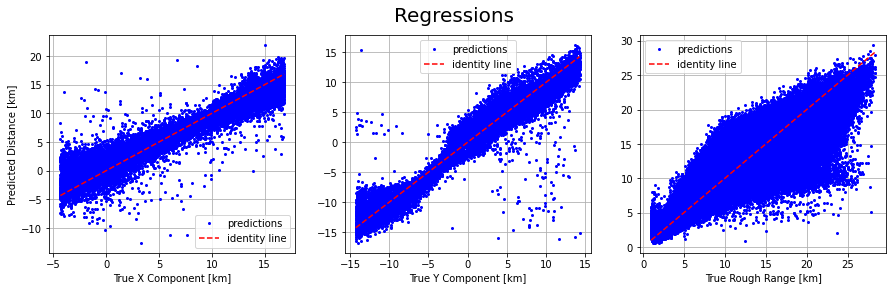

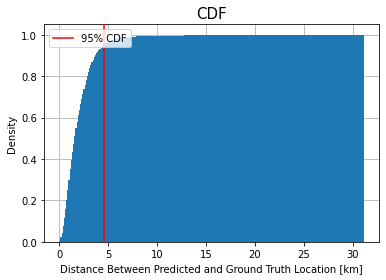

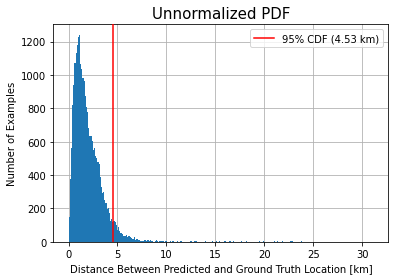

In [13]:
plot_regressions(r_t, r_p, c_t, c_p, locs, x_t, y_t, dl[split], valid=True)

### Display High Error Calls

In [13]:
def plot_top_k_error(x_t, y_t, locs, c_t, c_p, dataloader, k=5, highest=True, valid=True, plot_predicted=False):
    """
    Plot top/bottom-k error calls.
    
    Parameters
    ----------
    x_p : array-like
        list of predicted X components
    x_t : array-like
        list of true X components
    y_p : array-like
        list of predicted Y components
    y_t : array-like
        list of true Y components
    dataloader : torch.utils.data.DataLoader
        dataloader used to produce x_t, x_p, y_t, y_p
    k : int
        number of top/bottom error calls to plot
    highest : bool
        whether to plot the highest/lowest error calls
    valid : bool
        whether or not to use only valid examples (source at a true bathymetry location)
    plot_predicted : bool
        whether or not to plot the predicted or group truth gunshot locations
    """
    
    x_p = locs[:,[1]]
    y_p = locs[:,[0]]
    
    # get data, labels, and indices of split
    dataset = dataloader.dataset.data
    labels = dataloader.dataset.labels[:]
    
    if 'Sim' in type(dataloader.dataset).__name__:
        idx = dataloader.batch_sampler.idx
    else:
        idx = np.arange(dataset.shape[0])
        
    assert len(idx) >= k, "k must be <= the number of exampes in the dataset"
    
    # get valid examples only
    if valid:
        # make sure we have a dataloader
        assert dataloader is not None, "dataloader needed to produce valid examples"
        
        # make sure dataloader is for simulated data
        assert 'Sim' in type(dataloader.dataset).__name__, "'valid' flag only for simulated data."
        
        valid_labels = labels[idx,5].astype(int)
        x_t = x_t[valid_labels == 1,:]
        x_p = x_p[valid_labels == 1,:]
        y_t = y_t[valid_labels == 1,:]
        y_p = y_p[valid_labels == 1,:]
        idx = idx[valid_labels == 1]
        
    ones = np.where(((c_t + c_p) == 2).sum(axis=1) >= 3)[0]
    x_t = x_t[ones]
    x_p = x_p[ones]
    y_t = y_t[ones]
    y_p = y_p[ones]
    idx = idx[ones]
    
    # sum X/Y absolute errors and get indices from largest to smallest
    top_k_abs_err = np.sqrt((x_t - x_p) ** 2 + (y_t - y_p) ** 2)
    inds = top_k_abs_err.squeeze().argsort()[::-1][:k] if highest else top_k_abs_err.squeeze().argsort()[:k]
    
    # get number of sensors per call
    num_TOSSITs = dataset.shape[1]
    
    # initialize dataframe
    df = pd.DataFrame(columns=["GT-P Distance [m]", 
                               "Y-Component GT [m]",
                               "Y-Component P [m]",
                               "Y-Component Abs. Error [m]",
                               "X-Component GT [m]",  
                               "X-Component P [m]",
                               "X-Component Abs. Error [m]"])
    
    x_list, y_list = [], []
    for d in range(k):
        
        # store coordinates
        top_k_X = dataset[idx[inds[d]],...]
        if plot_predicted:
            x_list.append(x_p[inds[d]])
            y_list.append(y_p[inds[d]])
        else:
            x_list.append(labels[idx[inds[d]],1])
            y_list.append(labels[idx[inds[d]],0])
        
        # append row to dataframe
        df_row = pd.DataFrame({"GT-P Distance [m]": [np.around(top_k_abs_err[inds[d]][0], 2)],
                               "Y-Component GT [m]": [np.around(y_t[inds[d]].squeeze(), 2)],
                               "Y-Component P [m]": [np.around(y_p[inds[d]].squeeze(), 2)],
                               "Y-Component Abs. Error [m]": [np.around(np.abs(y_t[inds[d]].squeeze() - y_p[inds[d]].squeeze()), 2)],
                               "X-Component GT [m]": [np.around(x_t[inds[d]].squeeze(), 2)],
                               "X-Component P [m]": [np.around(x_p[inds[d]].squeeze(), 2)],
                               "X-Component Abs. Error [m]": [np.around(np.abs(x_t[inds[d]].squeeze() - x_p[inds[d]].squeeze()), 2)]})
        df = pd.concat([df, df_row], ignore_index=True)
        
        # only plot signals if fewer than 20 calls
        if k < 20:
            plt.figure()
            for t in range(num_TOSSITs):
                spect = to_spect(top_k_X[t])
                plt.subplot(1,num_TOSSITs, t+1)
                plt.imshow(spect.squeeze())
                plt.title(f"TOSSIT {t+1}")
                plt.axis('off')
            plt.tight_layout()
    
    # show dataframe tail if less than 20 signals
    if k < 20:
        display(df)
    else:
        display(df.head())
    
    # get correct location label for plot
    loc_label = 'predicted' if plot_predicted else 'ground truth' 
    
    # overlay points onto map
    plt.figure()
    img = Image.open(config['dataset']['data_directory'] + '/map.tif', mode='r', formats=None)
    plt.scatter(x_list, y_list, c='#0307fc', s=2, label=loc_label)
    plt.scatter(np.asarray(config['TOSSIT']['TOSSIT_x']), np.asarray(config['TOSSIT']['TOSSIT_y']), s=30, marker='x', label='TOSSIT')
    plt.gca().invert_yaxis()
    implot = plt.imshow(img, extent=(config['scaling']['min_x'], config['scaling']['max_x'], config['scaling']['max_y'], config['scaling']['min_y']))
    plt.legend(loc='lower left')
    plt.xlabel("X Component [m]")
    plt.ylabel("Y Component [m]")

,GT-P Distance [m],Y-Component GT [m],Y-Component P [m],Y-Component Abs. Error [m],X-Component GT [m],X-Component P [m],X-Component Abs. Error [m]
0,0.57,-1760.58,-1760.03,0.55,4963.73,4963.84,0.11
1,1.41,-1482.59,-1482.60,0.01,10686.22,10684.82,1.41
2,2.07,2965.19,2965.12,0.07,4001.22,4003.29,2.07
3,2.30,2131.23,2131.52,0.29,7518.66,7516.38,2.28
4,3.18,-3984.47,-3984.52,0.05,10889.21,10892.39,3.18


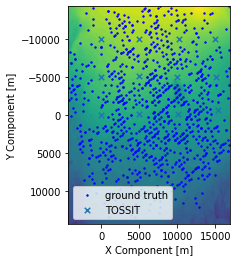

In [17]:
plot_top_k_error(x_t, 
                 y_t,
                 locs,
                 c_t, 
                 c_p,
                 dl[split],
                 highest=False,
                 k=1000,
                 valid=True)

## Evaluation Model On Experimental Data

run the network on all isolated experimental examples from all TOSSITs

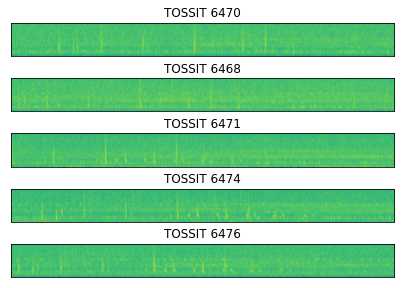

In [5]:
# load sandbox data
with h5py.File(config['dataset']['exp_data_directory'] + "/" + config['dataset']['sandbox_data_file'], "r") as f:
    data = f['data'][:]

# convert whole signals to spectrogram
data_spect = to_spect(data).squeeze()

# order of signals
names = ["6470", "6468", "6471", "6474", "6476"]

# load constants
mu_list = np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True)
std_list = np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True)
fs = config['signal']['fs']
T = config['signal']['T']
size = fs*T

fig, axs = plt.subplots(5, 1)
for c in range(data_spect.shape[0]):
    axs[c].imshow(data_spect[c], aspect=4)
    axs[c].set_title(f'TOSSIT {names[c]}')
    axs[c].set_xticks([])
    axs[c].set_yticks([])
fig.tight_layout()

In [8]:
# set parameters
data_params = {'mu_list' : np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
               'std_list' : np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True),
               'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}

# instantiate clip analyzer object
CA = ClipAnalyzer(model, data_params, preprocessor=l2_standardize, device=device)

# process all clips
res = CA.process_clips(data)

In [14]:
from scipy.signal import find_peaks, peak_widths

detection_vec = np.asarray([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0 ,0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1])
# detection_vec = np.asarray([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
#         1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
#         1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
#         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
#         0, 0, 0, 0, 0, 0, 0])

detection_vec = np.pad(detection_vec, 1)
detection_idx, _ = find_peaks(detection_vec, plateau_size=3)
detection_idx = detection_idx - 1

while True:
    diff = (np.diff(detection_idx) * (1 - 0.75) * 6) < 6
    diff = np.pad(diff, 1)
    peaks, prop = find_peaks(diff, plateau_size=1)
    
    print(detection_idx)
    print(diff)
    
    
    if not len(prop['plateau_sizes']):
        break
    
    to_delete = []
    for w, l, r in zip(prop['plateau_sizes'], prop['left_edges'], prop['right_edges']):
        to_delete.append(l + 1 if w > 1 else l)
    detection_idx = np.delete(detection_idx, to_delete)

[28 33]
[False False False]
